In [50]:
%load_ext autoreload
%autoreload 2
import segmentation_models_pytorch as smp
import torch
from matplotlib import pyplot as plt
import numpy as np
from torchvision.io import read_image
import pytorch3d
from pytorch_lightning import LightningModule, Trainer
from constraints.visu.helpers import show_torch_image

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [51]:
# try to overfit on one image and its mask
img = read_image("input.png")
mask = read_image("mask.png").float() / 255.0  # Normalize to [0, 1]
template = read_image("template.png").float() / 255.0  # Normalize to [0, 1]

print(mask.unique())
print(mask.shape)
mask_target = torch.zeros_like(mask[0], dtype=torch.long)  # Assuming the first channel contains the class labels
for c in range(mask.shape[0]):
    mask_target[mask[c] > 0] = c  # Assign class c where the mask is greater than 0
print(mask_target.unique())

tensor([0., 1.])
torch.Size([3, 256, 256])
tensor([0, 1, 2])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-34.41611..43.999783].


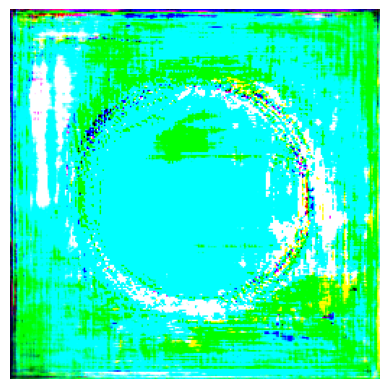

6
Layer 0: torch.Size([1, 1, 256, 256])
Layer 1: torch.Size([1, 64, 128, 128])
Layer 2: torch.Size([1, 64, 64, 64])
Layer 3: torch.Size([1, 128, 32, 32])
Layer 4: torch.Size([1, 256, 16, 16])
Layer 5: torch.Size([1, 512, 8, 8])


In [52]:
UNET = smp.Unet("resnet18", encoder_weights="imagenet", in_channels=1, classes=3)
# plainly test what happens
UNET.eval()
pred = UNET(img.unsqueeze(0).float())
show_torch_image(pred[0])
print(len(UNET.encoder(img.unsqueeze(0).float())))
for i, layer in enumerate(UNET.encoder(img.unsqueeze(0).float())):
    print(f"Layer {i}: {layer.shape}")


In [136]:
from constraints.transforms import differentiable_rotation
from constraints.losses import CentroidLoss
from constraints.utils import rad2deg,deg2rad

        


In [53]:
# # overfit only UNET branch
# UNET.train()
# optimizer = torch.optim.Adam(UNET.parameters(), lr=1e-3)
# criterion = torch.nn.CrossEntropyLoss()
# for epoch in range(100):
#     optimizer.zero_grad()
#     pred = UNET(img.unsqueeze(0).float())
#     loss = criterion(pred, mask_target.unsqueeze(0))
#     loss.backward()
#     optimizer.step()
#     if epoch % 10 == 0:
#         show_torch_image(torch.argmax(pred[0], dim=0))
#     print(f"Epoch {epoch}, Loss: {loss.item()}")

In [ ]:


def compute_chamfer_distance(pred_one_hot, gt_one_hot):
    # pred_one_hot and gt_one_hot shape: [B, C, H, W]
    device = pred_one_hot.device
    B, C, H, W = pred_one_hot.size()
    
    

In [122]:

converge_cnt = 0
for i in range(50):
    init = torch.randn(1) * deg2rad(30)
    angle = torch.nn.Parameter(torch.tensor([[init]]))
    opt = torch.optim.Adam([angle], lr=1e-2)
    for epoch in range(150):
        opt.zero_grad()
        rotated = differentiable_rotation(template.unsqueeze(0), angle)
        loss = torch.nn.functional.mse_loss(mask.float(), rotated)
        loss.backward()
        opt.step()

        # if epoch % 20 == 0:
        #     print(epoch, rad2deg(angle).item(), loss.item())
        
    if abs(rad2deg(angle).item() +10) < 0.1: #approx -10 degrees
        converge_cnt += 1
    
print("Converged for", converge_cnt, "out of 50 runs")

Converged for 46 out of 50 runs


In [130]:


# create a two-branch module
class TwoBranch(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.unet = smp.Unet("resnet18", encoder_weights="imagenet", in_channels=1, classes=3)
        # keep it simple - linear layer to each layer of the UNET encoder 
        self.projector = torch.nn.LazyConv2d(64,kernel_size=1)
        self.output_layer = torch.nn.Linear(64, 2)
        # angle = torch.nn.Parameter(torch.tensor([[0.0]]))
        # self.register_parameter("angle", angle)
    def forward(self, x):
        encoded = self.unet.encoder(x)
        bottleneck = encoded[-1]
        decoded = self.unet.segmentation_head(self.unet.decoder(encoded))
        projected = self.projector(bottleneck).mean(dim=(2,3))  # Global average pooling
        angle_vec = self.output_layer(projected)
        angle = torch.atan2(angle_vec[:, 0], angle_vec[:, 1]).view(-1, 1)
        # angle = self.angle
        return decoded, angle


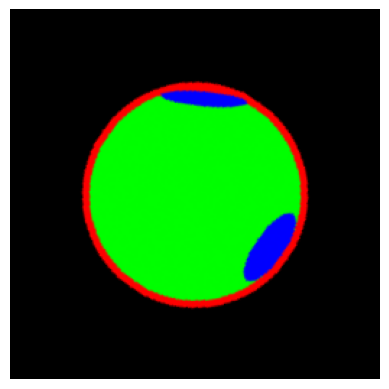

In [131]:
show_torch_image(differentiable_rotation(template.unsqueeze(0).float(), torch.tensor(-np.pi/4)))

TASK:
RESULT:
angle: -128.19342041015625


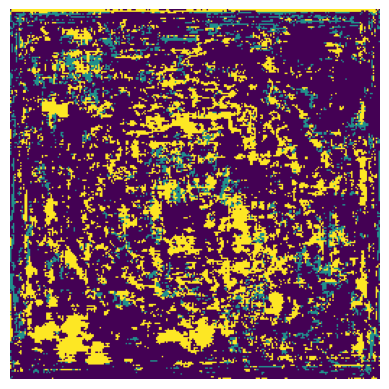

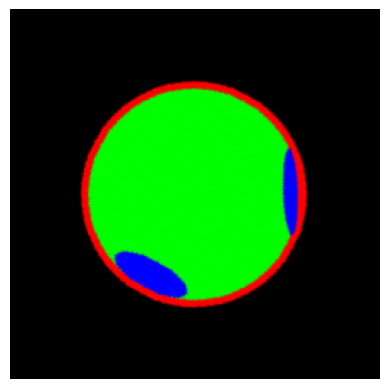

Epoch 0, Losses: 1.1836909055709839 3.908460855484009
angle: -44.05373001098633
Epoch 1, Losses: 0.8691744804382324 0.45539960265159607
angle: -17.275035858154297
Epoch 2, Losses: 0.7137860655784607 0.021397238597273827
angle: -9.317584037780762
Epoch 3, Losses: 0.5804791450500488 0.0001804670609999448
angle: -5.801990032196045
Epoch 4, Losses: 0.48712727427482605 0.007072191685438156
angle: -4.070699214935303
Epoch 5, Losses: 0.41651633381843567 0.014126132242381573
angle: -3.217848300933838
Epoch 6, Losses: 0.3547693192958832 0.018490048125386238
angle: -2.878209352493286
Epoch 7, Losses: 0.3103276491165161 0.02038927562534809
angle: -2.853630304336548
Epoch 8, Losses: 0.27405208349227905 0.020529791712760925
angle: -3.049830913543701
Epoch 9, Losses: 0.24281051754951477 0.01941791921854019
angle: -3.40158748626709


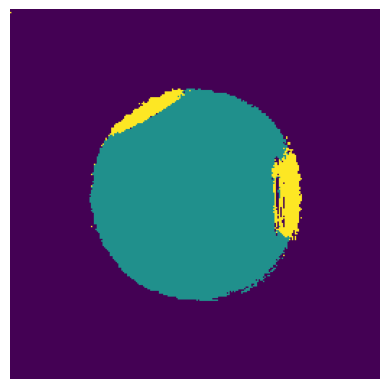

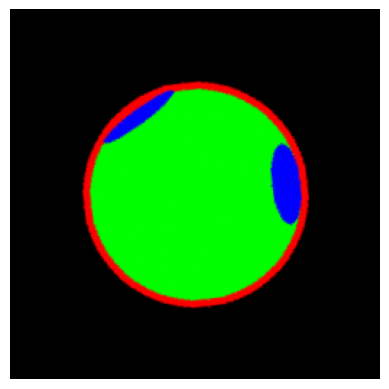

Epoch 10, Losses: 0.2168933004140854 0.017498889937996864
angle: -3.8511641025543213
Epoch 11, Losses: 0.1950569897890091 0.015194972045719624
angle: -4.376708507537842
Epoch 12, Losses: 0.17622783780097961 0.012705689296126366
angle: -4.94727087020874
Epoch 13, Losses: 0.15929751098155975 0.010250846855342388
angle: -5.559793472290039
Epoch 14, Losses: 0.1441982239484787 0.007909370586276054
angle: -6.18051290512085
Epoch 15, Losses: 0.1307489573955536 0.005847926717251539
angle: -6.802618503570557
Epoch 16, Losses: 0.11894767731428146 0.004095481708645821
angle: -7.408487319946289
Epoch 17, Losses: 0.10870160162448883 0.0026859764475375414
angle: -7.996006965637207
Epoch 18, Losses: 0.09950758516788483 0.00160119473002851
angle: -8.548218727111816
Epoch 19, Losses: 0.09116020053625107 0.000836757302749902
angle: -9.064894676208496


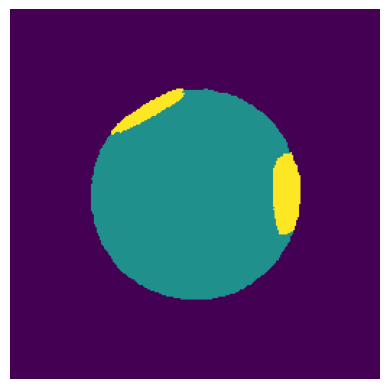

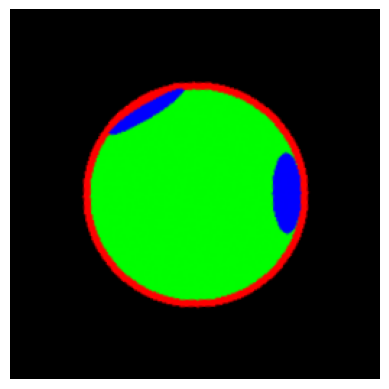

Epoch 20, Losses: 0.08370058238506317 0.0003435714461375028
angle: -9.53793716430664
Epoch 21, Losses: 0.07702073454856873 8.053681085584685e-05
angle: -9.967095375061035
Epoch 22, Losses: 0.07093736529350281 1.8920813715794793e-07
angle: -10.349261283874512
Epoch 23, Losses: 0.0654529556632042 5.408269862527959e-05
angle: -10.682591438293457
Epoch 24, Losses: 0.060621459037065506 0.0001985845301533118
angle: -10.966567039489746
Epoch 25, Losses: 0.056285008788108826 0.000389064138289541
angle: -11.200746536254883
Epoch 26, Losses: 0.052315883338451385 0.0005992854130454361
angle: -11.38427734375
Epoch 27, Losses: 0.0487469844520092 0.0007888134568929672
angle: -11.519603729248047
Epoch 28, Losses: 0.04564359039068222 0.0009487624047324061
angle: -11.605586051940918
Epoch 29, Losses: 0.04288396239280701 0.001057232148014009
angle: -11.646554946899414


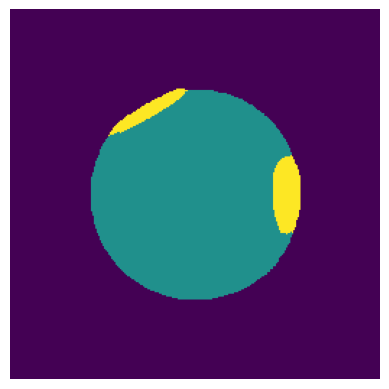

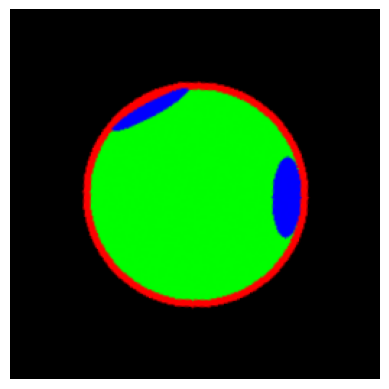

Epoch 30, Losses: 0.04029671475291252 0.0011131861247122288
angle: -11.650252342224121
Epoch 31, Losses: 0.037958648055791855 0.0011176562402397394
angle: -11.61934757232666
Epoch 32, Losses: 0.035935889929533005 0.001077010645531118
angle: -11.550427436828613
Epoch 33, Losses: 0.03408209979534149 0.0009879866847768426
angle: -11.451570510864258
Epoch 34, Losses: 0.03231549263000488 0.0008623882313258946
angle: -11.327884674072266
Epoch 35, Losses: 0.030727606266736984 0.0007292092777788639
angle: -11.18519115447998
Epoch 36, Losses: 0.029358670115470886 0.0005834634648635983
angle: -11.027589797973633
Epoch 37, Losses: 0.028109734877943993 0.00043802495929412544
angle: -10.85867691040039
Epoch 38, Losses: 0.02690885029733181 0.00030732579762116075
angle: -10.686384201049805
Epoch 39, Losses: 0.025791417807340622 0.00020063944975845516
angle: -10.514469146728516


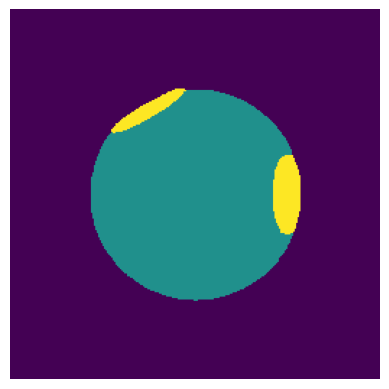

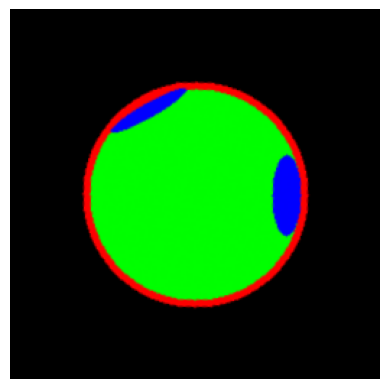

Epoch 40, Losses: 0.0247854832559824 0.00011418639041949064
angle: -10.34653091430664
Epoch 41, Losses: 0.023846464231610298 5.3264302550815046e-05
angle: -10.185845375061035
Epoch 42, Losses: 0.02296115830540657 1.5996229194570333e-05
angle: -10.036487579345703
Epoch 43, Losses: 0.022162960842251778 1.0176396472161287e-06
angle: -9.899889945983887
Epoch 44, Losses: 0.02142348140478134 2.9762950362055562e-06
angle: -9.77846622467041
Epoch 45, Losses: 0.020716767758131027 1.800499921955634e-05
angle: -9.67364501953125
Epoch 46, Losses: 0.020059775561094284 3.976692460128106e-05
angle: -9.586506843566895
Epoch 47, Losses: 0.01946098729968071 6.488394137704745e-05
angle: -9.517559051513672
Epoch 48, Losses: 0.018900196999311447 8.821125811664388e-05
angle: -9.4672269821167
Epoch 49, Losses: 0.018359946087002754 0.00010885956726269796
angle: -9.434350967407227


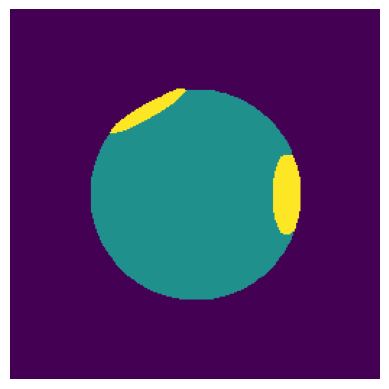

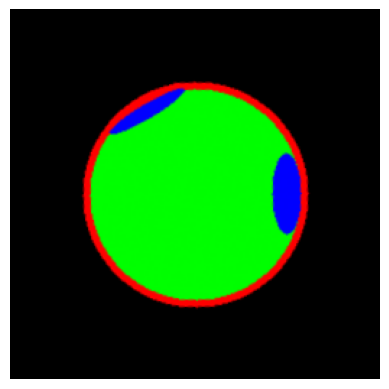

Epoch 50, Losses: 0.017860835418105125 0.00012302813411224633
angle: -9.418490409851074
Epoch 51, Losses: 0.017386024817824364 0.00013016148295719177
angle: -9.418024063110352
Epoch 52, Losses: 0.016927212476730347 0.0001303705939790234
angle: -9.432271957397461
Epoch 53, Losses: 0.016494544222950935 0.00012393052747938782
angle: -9.459314346313477
Epoch 54, Losses: 0.016094394028186798 0.00011208985233679414
angle: -9.497314453125
Epoch 55, Losses: 0.015713058412075043 9.613156726118177e-05
angle: -9.544357299804688
Epoch 56, Losses: 0.015346936881542206 7.836290751583874e-05
angle: -9.598013877868652
Epoch 57, Losses: 0.015000708401203156 6.120913167251274e-05
angle: -9.657197952270508
Epoch 58, Losses: 0.014675836078822613 4.404142600833438e-05
angle: -9.719392776489258
Epoch 59, Losses: 0.014370264485478401 2.9269953301991336e-05
angle: -9.782726287841797


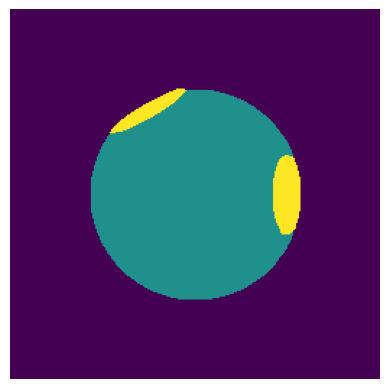

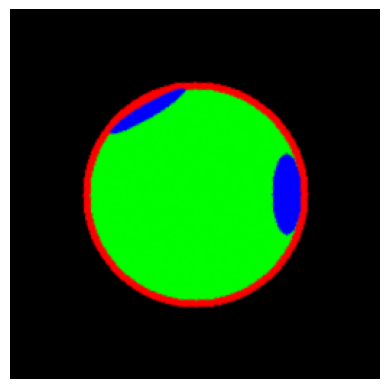

Epoch 60, Losses: 0.014072821475565434 1.7266040231334046e-05
angle: -9.845993041992188
Epoch 61, Losses: 0.013787897303700447 8.205116500903387e-06
angle: -9.907590866088867
Epoch 62, Losses: 0.013517903164029121 2.3871125449659303e-06
angle: -9.965710639953613
Epoch 63, Losses: 0.013259843923151493 2.084446464323264e-07
angle: -10.018645286560059
Epoch 64, Losses: 0.0130086001008749 3.7862517388020933e-07
angle: -10.065649032592773
Epoch 65, Losses: 0.012769189663231373 2.735496309469454e-06
angle: -10.105560302734375
Epoch 66, Losses: 0.01254209689795971 6.151948127808282e-06
angle: -10.138137817382812
Epoch 67, Losses: 0.012321572750806808 9.625386155676097e-06
angle: -10.163406372070312
Epoch 68, Losses: 0.012109285220503807 1.2827856153307948e-05
angle: -10.180946350097656
Epoch 69, Losses: 0.0119063975289464 1.5351628462667577e-05
angle: -10.191680908203125


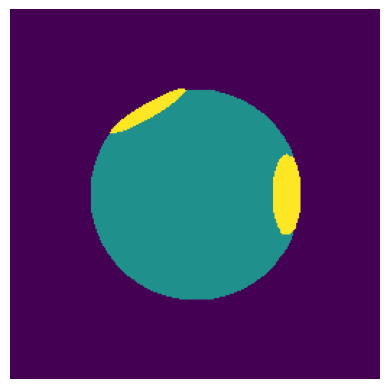

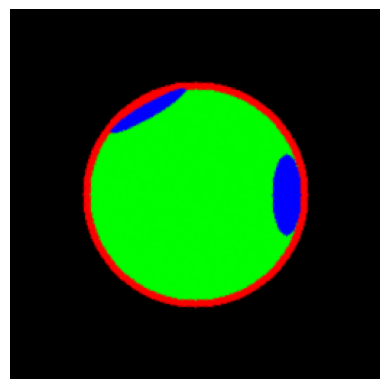

Epoch 70, Losses: 0.011709141544997692 1.677277214184869e-05
angle: -10.196283340454102
Epoch 71, Losses: 0.011519081890583038 1.7426740669179708e-05
angle: -10.195003509521484
Epoch 72, Losses: 0.011336300522089005 1.7238160580745898e-05
angle: -10.188553810119629
Epoch 73, Losses: 0.01115823071449995 1.6354271792806685e-05
angle: -10.177742004394531
Epoch 74, Losses: 0.0109865078702569 1.4907153854437638e-05
angle: -10.162781715393066
Epoch 75, Losses: 0.010820032097399235 1.2734320080198813e-05
angle: -10.143583297729492
Epoch 76, Losses: 0.01065919827669859 1.0284737072652206e-05
angle: -10.121463775634766
Epoch 77, Losses: 0.010502973571419716 7.765158443362452e-06
angle: -10.097503662109375
Epoch 78, Losses: 0.010352004319429398 5.374729880713858e-06
angle: -10.072258949279785
Epoch 79, Losses: 0.01020530704408884 3.2579016533418326e-06
angle: -10.046323776245117


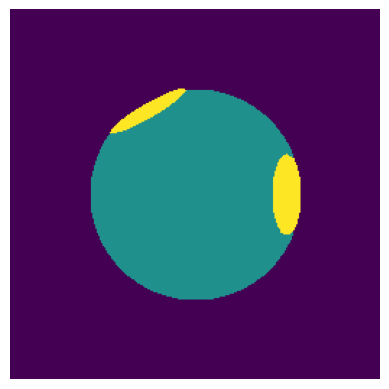

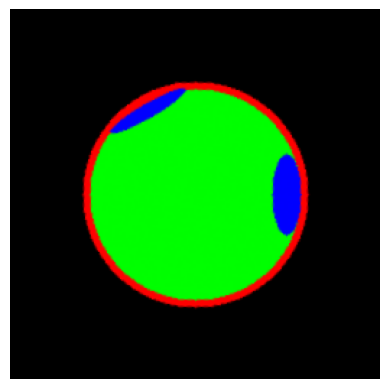

Epoch 80, Losses: 0.010062082670629025 1.47385912896425e-06
angle: -10.020764350891113
Epoch 81, Losses: 0.009923267178237438 4.358870455689612e-07
angle: -9.996335983276367
Epoch 82, Losses: 0.00978793017566204 5.7408982456763624e-08
angle: -9.974011421203613
Epoch 83, Losses: 0.009655723348259926 1.1178635617170585e-07
angle: -9.954255104064941
Epoch 84, Losses: 0.009527298621833324 4.1886906387844647e-07
angle: -9.937277793884277
Epoch 85, Losses: 0.00940242875367403 9.036436381393287e-07
angle: -9.923309326171875
Epoch 86, Losses: 0.009280444122850895 1.4675832744615036e-06
angle: -9.912556648254395
Epoch 87, Losses: 0.009160819463431835 2.0399816094140988e-06
angle: -9.905367851257324
Epoch 88, Losses: 0.009045349434018135 2.5541626200720202e-06
angle: -9.902000427246094
Epoch 89, Losses: 0.00893215648829937 2.8135864340583794e-06
angle: -9.902262687683105


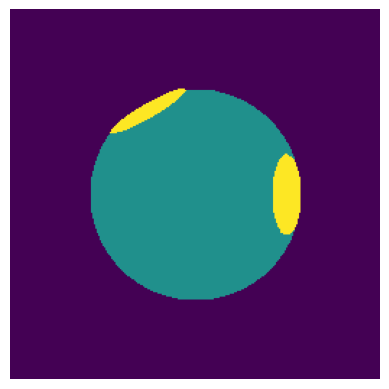

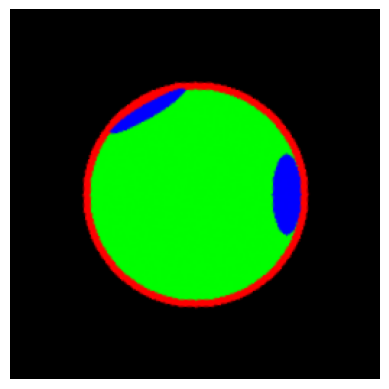

Epoch 90, Losses: 0.008821722120046616 2.7933454020967474e-06
angle: -9.905733108520508
Epoch 91, Losses: 0.008713985793292522 2.5265023850806756e-06
angle: -9.911968231201172
Epoch 92, Losses: 0.008608461357653141 2.0776960809598677e-06
angle: -9.92041015625
Epoch 93, Losses: 0.008505272679030895 1.6068014474512893e-06
angle: -9.930122375488281
Epoch 94, Losses: 0.008404122665524483 1.1729135849236627e-06
angle: -9.940583229064941
Epoch 95, Losses: 0.00830555334687233 7.904655490165169e-07
angle: -9.951519012451172
Epoch 96, Losses: 0.008209153078496456 4.830197326555208e-07
angle: -9.96233081817627
Epoch 97, Losses: 0.008114037103950977 2.599414301585057e-07
angle: -9.97280502319336
Epoch 98, Losses: 0.0080215223133564 1.2342746913418523e-07
angle: -9.982758522033691
Epoch 99, Losses: 0.007931212894618511 4.87129945270226e-08


In [137]:
torch.manual_seed(22)
model = TwoBranch()
model.train()

# Materialize LazyConv2d parameters before creating the optimizer.
with torch.no_grad():
    model(img.unsqueeze(0).float())

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss1 = torch.nn.CrossEntropyLoss()
loss2 = CentroidLoss()

print("TASK:")
# show_torch_image(mask)
# show_torch_image(template)
print("RESULT:")
H,W = mask.shape[1], mask.shape[2]
for epoch in range(100):
    optimizer.zero_grad()
    decoded, angle = model(img.unsqueeze(0).float())
    rotated_template = differentiable_rotation(template.float().unsqueeze(0), angle)
    print("angle:", rad2deg(angle).item())
    loss1_val = loss1(decoded, mask_target.unsqueeze(0))
    loss2_val =  100 * loss2(mask.float().unsqueeze(0), rotated_template.unsqueeze(0))
    loss = loss1_val + loss2_val
    loss.backward()
    
    optimizer.step()
    if epoch % 10 == 0:
        show_torch_image(torch.argmax(decoded[0], dim=0))
        show_torch_image(rotated_template)
        
    print(f"Epoch {epoch}, Losses: {loss1_val.item()} {loss2_val.item()}")